In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

PATH = "aggregated_results.csv"
df = pd.read_csv(PATH)

# Keep only rows that are real amplicon features (Classification present)
df_feat = df[df["Classification"].notna()].copy()

# ---- helpers to parse list-like columns safely ----
def _parse_list_cell(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        raw = x
    else:
        try:
            raw = ast.literal_eval(str(x))
        except Exception:
            return []
    if not isinstance(raw, list):
        return []
    out = []
    for item in raw:
        s = str(item).strip()
        s = s.strip("'").strip('"').strip()
        if s and s.lower() != "nan":
            out.append(s)
    return out

df_feat["oncogenes_list"] = df_feat["Oncogenes"].apply(_parse_list_cell)
df_feat["all_genes_list"] = df_feat["All genes"].apply(_parse_list_cell)

# numeric columns (coerce)
num_cols = [
    "Captured interval length",
    "Feature median copy number",
    "Feature maximum copy number",
    "Complexity score",
]
for c in num_cols:
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")

print("Rows:", df.shape, "Feature-rows:", df_feat.shape)
print("Classifications:", df_feat["Classification"].value_counts().to_dict())


Rows: (1234, 30) Feature-rows: (1157, 32)
Classifications: {'Linear': 550, 'ecDNA': 297, 'Complex-non-cyclic': 196, 'BFB': 114}


# 1)Is YES1 amplified as ecDNA or BFB in CCLE? In which samples?

In [2]:
gene = "YES1"

hits = df_feat[
    df_feat["oncogenes_list"].apply(lambda xs: gene in xs)
    | df_feat["all_genes_list"].apply(lambda xs: gene in xs)
].copy()

summary = (
    hits.groupby("Classification")["Sample name"]
    .nunique()
    .sort_values(ascending=False)
)

print("Unique samples with YES1 amplification by class:")
print(summary)

print("\nExample rows (sample, class, feature, locus):")
cols = ["Sample name", "Classification", "Feature ID", "Location",
        "Captured interval length", "Feature maximum copy number"]
print(hits[cols].sort_values(["Classification","Sample name"]).head(30).to_string(index=False))


Unique samples with YES1 amplification by class:
Classification
BFB    1
Name: Sample name, dtype: int64

Example rows (sample, class, feature, locus):
      Sample name Classification                        Feature ID                   Location  Captured interval length  Feature maximum copy number
KYSE70_OESOPHAGUS            BFB KYSE70_OESOPHAGUS_amplicon7_BFB_1 ["'chr18:634973-4361110'"]                 3726137.0                    21.688132


# 2)Summarize the size distribution of all BFB amplifications (Captured interval length)

BFB count: 114 with size: 114
count    1.140000e+02
mean     2.271737e+06
std      2.991727e+06
min      5.946300e+04
10%      2.033848e+05
25%      5.037368e+05
50%      1.276367e+06
75%      2.929109e+06
90%      5.312285e+06
max      2.124683e+07
Name: Captured interval length, dtype: float64


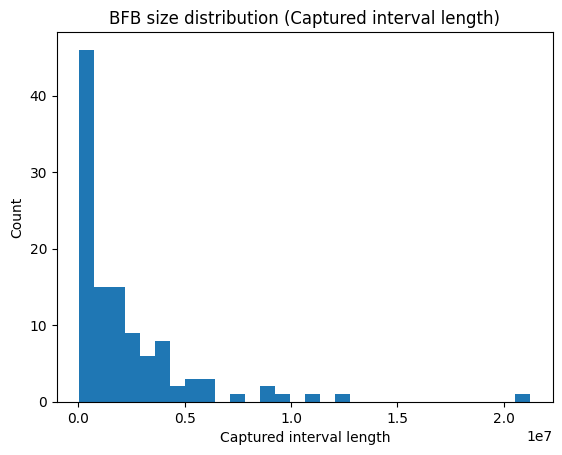

In [9]:
bfb = df_feat[df_feat["Classification"].eq("BFB")].copy()
sizes = bfb["Captured interval length"].dropna()

print("BFB count:", len(bfb), "with size:", sizes.notna().sum())
print(sizes.describe(percentiles=[0.1,0.25,0.5,0.75,0.9]))

plt.figure()
plt.hist(sizes, bins=30)
plt.xlabel("Captured interval length")
plt.ylabel("Count")
plt.title("BFB size distribution (Captured interval length)")
plt.show()


# 3)List all BFB amplifications in HARA (feature IDs, loci, genes, copy number)

In [11]:
sample = "HARA_LUNG"
bt = df_feat[(df_feat["Sample name"] == sample) & (df_feat["Classification"] == "BFB")].copy()

cols = [
    "Sample name","Classification","AA amplicon number","Feature ID","Location",
    "Captured interval length","Feature median copy number","Feature maximum copy number",
    "Oncogenes","All genes"
]
print("BFB features in", sample, ":", len(bt))
print(bt[cols].sort_values(["AA amplicon number","Feature ID"]).to_string(index=False))

BFB features in HARA_LUNG : 1
Sample name Classification  AA amplicon number                Feature ID                                                   Location  Captured interval length  Feature median copy number  Feature maximum copy number   Oncogenes                                                                                                                                                                              All genes
  HARA_LUNG            BFB                 6.0 HARA_LUNG_amplicon6_BFB_1 ["'chr11:34893970-37730986'", "'chr11:37761005-41072281'"]                 6148292.0                   15.180671                    56.560276 ["'TRAF6'"] ["'APIP'", "'C11orf74'", "'CD44'", "'COMMD9'", "'FJX1'", "'LDLRAD3'", "'LRRC4C'", "'PAMR1'", "'PDHX'", "'PRR5L'", "'RAG1'", "'RAG2'", "'SLC1A2'", "'SNORD164'", "'TRAF6'", "'TRIM44'"]


# 4) Which genes are most frequently amplified as BFB? (top 25)

In [12]:
from collections import Counter

bfb = df_feat[df_feat["Classification"].eq("BFB")].copy()

ctr = Counter()
for genes in bfb["oncogenes_list"]:
    ctr.update(set(genes))  # set() to avoid double-counting within one feature

top = pd.DataFrame(ctr.most_common(25), columns=["Gene","BFB_feature_count"])
print(top.to_string(index=False))

 Gene  BFB_feature_count
 CTTN                  5
 MYCL                  4
 FGF4                  4
CCND1                  4
 FGF3                  4
TRAF6                  3
 YAP1                  3
MMP12                  3
BIRC2                  3
BIRC3                  3
MIEN1                  3
CDK12                  3
ERBB2                  3
 LDHB                  2
CCNE1                  2
 URI1                  2
ACTN4                  2
 AKT2                  2
 CRKL                  2
  MYC                  2
 PVT1                  2
  KDR                  2
  KIT                  2
MLLT6                  2
LASP1                  2


# 5) Show the distribution of amplification classes across cancer types (Tissue of origin)

Classification                      BFB  Complex-non-cyclic  Linear  ecDNA
Tissue of origin                                                          
autonomic ganglia                     0                   0       0      1
bone                                  1                   0       1      0
breast                               13                  32     101     62
central nervous system                0                   5       7      6
endometrium                           2                   5      14     12
haematopoietic and lymphoid tissue    0                   5      18      5
kidney                                2                   0       3      2
large intestine                       3                   7      12      4
liver                                 4                   8       8      5
lung                                 43                  67     193    104
oesophagus                           11                  12      40     21
ovary                    

<Figure size 640x480 with 0 Axes>

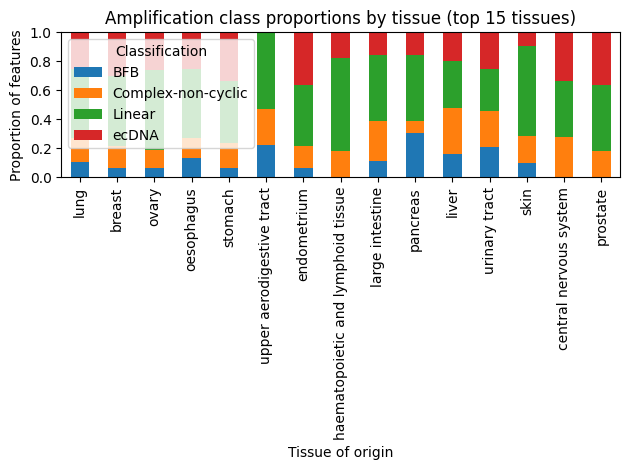

In [13]:
tab = pd.crosstab(df_feat["Tissue of origin"], df_feat["Classification"]).sort_index()
print(tab.head(20))

# Also show proportions per tissue
prop = tab.div(tab.sum(axis=1), axis=0).fillna(0)
print("\nProportions (first 20 tissues):")
print(prop.head(20))

# Plot top tissues by total feature count
top_tissues = tab.sum(axis=1).sort_values(ascending=False).head(15).index
plt.figure()
prop.loc[top_tissues].plot(kind="bar", stacked=True)
plt.ylabel("Proportion of features")
plt.title("Amplification class proportions by tissue (top 15 tissues)")
plt.tight_layout()
plt.show()


# 6) For each tissue, what fraction of samples have any ecDNA?

Top 25 tissues by ecDNA-sample fraction:
Tissue of origin
autonomic ganglia                     1.000000
thyroid                               1.000000
oesophagus                            1.000000
ovary                                 0.882353
breast                                0.787879
lung                                  0.670455
stomach                               0.631579
central nervous system                0.625000
endometrium                           0.600000
prostate                              0.500000
haematopoietic and lymphoid tissue    0.500000
large intestine                       0.500000
liver                                 0.500000
pleura                                0.500000
urinary tract                         0.428571
kidney                                0.400000
pancreas                              0.375000
skin                                  0.166667
soft tissue                           0.000000
bone                                  0.000000
up

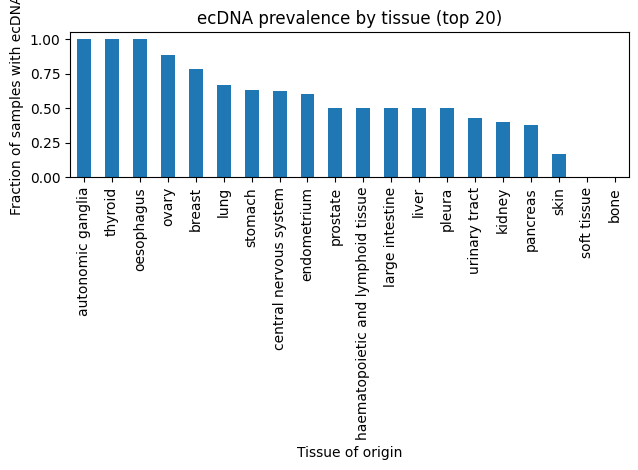

In [14]:
# sample-level: does a sample have >=1 ecDNA feature?
sample_has_ec = (
    df_feat.assign(has_ecDNA=df_feat["Classification"].eq("ecDNA"))
          .groupby(["Tissue of origin","Sample name"])["has_ecDNA"]
          .any()
          .reset_index()
)

tissue_frac = (
    sample_has_ec.groupby("Tissue of origin")["has_ecDNA"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 25 tissues by ecDNA-sample fraction:")
print(tissue_frac.head(25))

plt.figure()
tissue_frac.head(20).plot(kind="bar")
plt.ylabel("Fraction of samples with ecDNA")
plt.title("ecDNA prevalence by tissue (top 20)")
plt.tight_layout()
plt.show()


# 7) Do Complexity scores differ between ecDNA vs BFB vs Linear vs Complex-non-cyclic?

                    count      mean       std       min       25%       50%  \
Classification                                                                
BFB                 114.0  1.063654  0.256257  0.474421  0.887858  1.021014   
Complex-non-cyclic  196.0  1.261700  0.448434  0.222816  0.921391  1.189101   
Linear              550.0  0.580827  0.366532  0.000000  0.376822  0.636480   
ecDNA               297.0  0.840714  0.394129  0.133345  0.601398  0.686838   

                         75%       max  
Classification                          
BFB                 1.218679  1.758271  
Complex-non-cyclic  1.533952  2.660781  
Linear              0.810626  1.845296  
ecDNA               1.012470  2.357014  


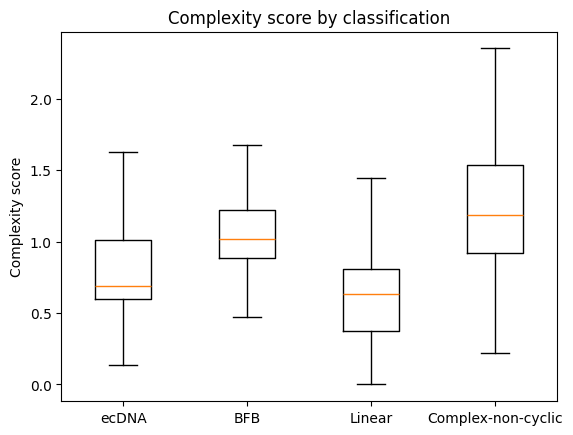

In [15]:
x = df_feat[["Classification","Complexity score"]].dropna().copy()

stats = x.groupby("Classification")["Complexity score"].describe(percentiles=[0.25,0.5,0.75])
print(stats)

# simple boxplot (matplotlib)
classes = ["ecDNA","BFB","Linear","Complex-non-cyclic"]
data = [x.loc[x["Classification"].eq(c),"Complexity score"].values for c in classes if c in x["Classification"].unique()]

plt.figure()
plt.boxplot(data, tick_labels=[c for c in classes if c in x["Classification"].unique()], showfliers=False)
plt.ylabel("Complexity score")
plt.title("Complexity score by classification")
plt.show()
    

# 8) For ecDNA vs BFB, how does size relate to max copy number? (scatter + correlation)

ecDNA: n=297 corr(size, maxCN)=0.0498
BFB: n=114 corr(size, maxCN)=-0.0029


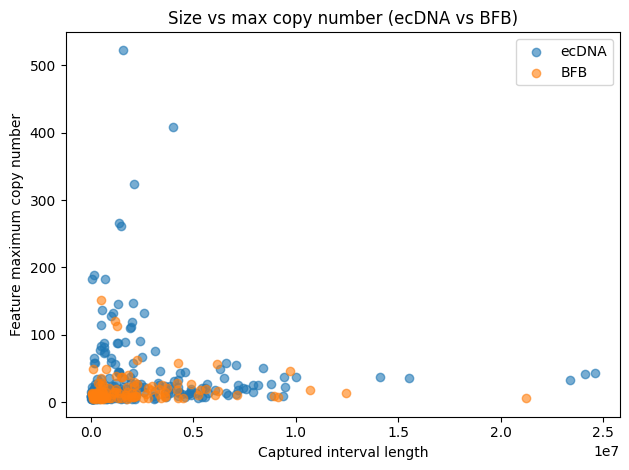

In [16]:
sub = df_feat[df_feat["Classification"].isin(["ecDNA","BFB"])].copy()
sub = sub.dropna(subset=["Captured interval length","Feature maximum copy number"])

# correlations per class
for cls in ["ecDNA","BFB"]:
    s = sub[sub["Classification"] == cls]
    corr = s["Captured interval length"].corr(s["Feature maximum copy number"])
    print(f"{cls}: n={len(s)} corr(size, maxCN)={corr:.4f}")

# scatter
plt.figure()
for cls in ["ecDNA","BFB"]:
    s = sub[sub["Classification"] == cls]
    plt.scatter(s["Captured interval length"], s["Feature maximum copy number"], label=cls, alpha=0.6)
plt.xlabel("Captured interval length")
plt.ylabel("Feature maximum copy number")
plt.title("Size vs max copy number (ecDNA vs BFB)")
plt.legend()
plt.tight_layout()
plt.show()


# 9) What are the highest copy-number amplifications in CCLE? (top 5)

In [18]:
top = (
    df_feat.dropna(subset=["Feature maximum copy number"])
          .sort_values("Feature maximum copy number", ascending=False)
          .head(5)
)

cols = ["Sample name","Tissue of origin","Classification","Feature ID","Location",
        "Feature maximum copy number","Feature median copy number","Captured interval length","Oncogenes"]
print(top[cols].to_string(index=False))


    Sample name Tissue of origin Classification                        Feature ID                                                                                                                                                                                                                                                                                                                                                                             Location  Feature maximum copy number  Feature median copy number  Captured interval length                                                     Oncogenes
   NCIH524_LUNG             lung          ecDNA    NCIH524_LUNG_amplicon2_ecDNA_1                                                                                                                                                                                                                                                                                           ["'chr8:120528251-120544068'", "'chr

# 10) Which oncogenes appear in both ecDNA and BFB across CCLE?

In [20]:
from collections import defaultdict

gene_classes = defaultdict(set)

for _, r in df_feat.iterrows():
    for g in r["oncogenes_list"]:
        gene_classes[g].add(r["Classification"])

both = sorted([g for g, cls in gene_classes.items() if {"ecDNA","BFB"} <= cls])

print("Genes appearing in both ecDNA and BFB:")
print(both)
print("Count:", len(both))


Genes appearing in both ecDNA and BFB:
['ARID2', 'ARNT', 'BIRC2', 'BIRC3', 'BRF2', 'CAV1', 'CCND1', 'CCND3', 'CCNE1', 'CDK12', 'CHIC2', 'COPS3', 'CSF3', 'CSF3R', 'CTTN', 'EGFR', 'EMSY', 'ERBB2', 'FGF3', 'FGF4', 'FIP1L1', 'FOXA1', 'FOXG1', 'GAB2', 'INTS3', 'INTS4', 'KDR', 'KIT', 'KRAS', 'LASP1', 'LDHB', 'MCL1', 'MDM2', 'MECOM', 'MET', 'MIEN1', 'MLANA', 'MLLT11', 'MLLT6', 'MMP12', 'MPL', 'MYC', 'MYCL', 'NKX2-1', 'PAK1', 'PDGFRA', 'PRKCI', 'PRMT5', 'PVT1', 'RPL23', 'RSF1', 'SEC62', 'SETDB1', 'SFPQ', 'SKIL', 'SMURF1', 'SREBF1', 'TFEB', 'THRA', 'THRAP3', 'TRAF6', 'TRIO', 'URI1', 'WNT2', 'YAP1', 'YEATS4', 'ZNF703']
Count: 67


# 12) Which samples contain both ecDNA and BFB amplifications?

In [23]:
sample_classes = (
    df_feat.groupby("Sample name")["Classification"]
    .apply(set)
)

both = sample_classes[sample_classes.apply(lambda x: {"ecDNA","BFB"} <= x)]
print("Samples with both ecDNA and BFB:")
print(both.index.tolist())
print("Count:", len(both))


Samples with both ecDNA and BFB:
['ABC1_LUNG', 'AU565_BREAST', 'BT20_BREAST', 'CHAGOK1_LUNG', 'CORL88_LUNG', 'COV644_OVARY', 'DANG_PANCREAS', 'DMS114_LUNG', 'DMS273_LUNG', 'EBC1_LUNG', 'EFM19_BREAST', 'HARA_LUNG', 'HCC1500_BREAST', 'HCC1599_BREAST', 'HCC1954_BREAST', 'HCC38_BREAST', 'HCC827_LUNG', 'HCC95_LUNG', 'JHH7_LIVER', 'KLE_ENDOMETRIUM', 'KYSE180_OESOPHAGUS', 'KYSE30_OESOPHAGUS', 'KYSE410_OESOPHAGUS', 'KYSE70_OESOPHAGUS', 'MDAMB157_BREAST', 'MDAMB175VII_BREAST', 'MDAMB453_BREAST', 'MKN1_STOMACH', 'MKN74_STOMACH', 'NCIH1092_LUNG', 'NCIH1435_LUNG', 'NCIH1651_LUNG', 'NCIH1694_LUNG', 'NCIH1792_LUNG', 'NCIH1876_LUNG', 'NCIH2029_LUNG', 'NCIH2066_LUNG', 'NCIH2170_LUNG', 'NCIH2171_LUNG', 'NCIH3255_LUNG', 'NCIH520_LUNG', 'NCIH650_LUNG', 'NCIH661_LUNG', 'NCIH889_LUNG', 'NIHOVCAR3_OVARY', 'OE19_OESOPHAGUS', 'OV90_OVARY', 'RMGI_OVARY', 'SCABER_URINARY_TRACT', 'SNU182_LIVER', 'TE11_OESOPHAGUS']
Count: 51


# 13) Are ecDNA amplifications larger than BFB on average?

In [25]:
sizes = (
    df_feat[df_feat["Classification"].isin(["ecDNA","BFB"])]
    .groupby("Classification")["Captured interval length"]
    .describe()
)

print(sizes)


                count          mean           std      min        25%  \
Classification                                                          
BFB             114.0  2.271737e+06  2.991727e+06  59463.0  503736.75   
ecDNA           297.0  2.096639e+06  3.299880e+06  10387.0  260748.00   

                      50%         75%         max  
Classification                                     
BFB             1276367.0  2929108.75  21246834.0  
ecDNA            985738.0  2233311.00  24593843.0  


# 14) Which samples have high-copy (>20 CN) ecDNA?

In [5]:
hc = df_feat[
    (df_feat["Classification"] == "ecDNA") &
    (df_feat["Feature maximum copy number"] > 20)
]

print(hc[["Sample name","Location","Feature maximum copy number","Oncogenes"]])


                                  Sample name  \
2                          5637_URINARY_TRACT   
5                                   59M_OVARY   
12                              8305C_THYROID   
35                               AU565_BREAST   
55                               BT474_BREAST   
...                                       ...   
1148                             SNU475_LIVER   
1155            SW1783_CENTRAL_NERVOUS_SYSTEM   
1199  THP1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE   
1212                           UACC812_BREAST   
1219                           UACC893_BREAST   

                                               Location  \
2                          ["'chr6:20350615-22839372'"]   
5     ["'chr8:52712046-56014576'", "'chr8:65533018-6...   
12    ["'chr20:34283685-34285398'", "'chr20:34299250...   
35    ["'chr8:71754758-71754831'", "'chr8:71755523-7...   
55    ["'chr20:44404279-45225559'", "'chr20:49762732...   
...                                                 ...  

# 15) What is the largest amplicon (by size) per class?

In [6]:
largest = (
    df_feat.sort_values("Captured interval length", ascending=False)
    .groupby("Classification")
    .head(1)
)

cols = ["Classification","Sample name","Location","Captured interval length","Oncogenes"]
print(largest[cols].to_string(index=False))


    Classification                     Sample name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

# 16) Which tissues show highest amplification complexity (median)?

In [7]:
tissue_complexity = (
    df_feat.groupby("Tissue of origin")["Complexity score"]
    .median()
    .sort_values(ascending=False)
)

print(tissue_complexity.head(20))


Tissue of origin
pleura                                1.248873
autonomic ganglia                     1.176241
soft tissue                           1.129679
liver                                 0.973848
large intestine                       0.961082
kidney                                0.872199
urinary tract                         0.869917
pancreas                              0.840527
skin                                  0.810184
upper aerodigestive tract             0.807988
stomach                               0.788245
central nervous system                0.759224
lung                                  0.719535
ovary                                 0.691793
oesophagus                            0.688151
haematopoietic and lymphoid tissue    0.681421
breast                                0.681368
endometrium                           0.676187
prostate                              0.664281
thyroid                               0.591204
Name: Complexity score, dtype: float64


# 17) For a given gene, list all co-amplified genes (same feature)

In [8]:
gene = "EGFR"

co = set()
for _, r in df_feat.iterrows():
    if gene in r["all_genes_list"]:
        co |= set(r["all_genes_list"])

co.discard(gene)
print("Co-amplified genes with", gene)
print(sorted(co))


Co-amplified genes with EGFR
['CALN1', 'CCT6A', 'COBL', 'DDC', 'DDC-AS1', 'EGFR-AS1', 'ELDR', 'FIGNL1', 'FKBP9P1', 'GRB10', 'IKZF1', 'LANCL2', 'MRPS17', 'NIPSNAP2', 'POM121L12', 'PSPH', 'SEC61G', 'SEPTIN14', 'SPATA48', 'UBE2J2', 'VOPP1', 'VSTM2A', 'VSTM2A-OT1', 'ZNF713', 'ZPBP']


# 18) Which genes are exclusive to ecDNA (never BFB or Linear)?

In [9]:
gene_cls = defaultdict(set)

for _, r in df_feat.iterrows():
    for g in r["oncogenes_list"]:
        gene_cls[g].add(r["Classification"])

exclusive = sorted([g for g,c in gene_cls.items() if c == {"ecDNA"}])
print("ecDNA-exclusive genes:", exclusive)


ecDNA-exclusive genes: ['AHI1', 'AKTIP', 'ARAF', 'ATM', 'BAALC', 'BCAR4', 'BCL7A', 'BMI1', 'CAD', 'CARD11', 'CBLL1', 'CD24', 'CIITA', 'COPS5', 'COX6C', 'CSNK2A1', 'CTNNB1', 'DDHD2', 'DDX10', 'DDX6', 'DUSP26', 'EIF3E', 'ELK1', 'FGFR2', 'FUS', 'FZD2', 'GNA12', 'GOPC', 'HEY1', 'HMGA2', 'IFNG', 'IGF2BP1', 'IKZF1', 'JUN', 'JUP', 'KMT2A', 'KSR2', 'LSM1', 'MALT1', 'MAML2', 'MAP2K4', 'MAP3K8', 'MNAT1', 'MSI2', 'MTDH', 'MYB', 'MYCN', 'NANOG', 'NCOA3', 'NME1', 'OTX2', 'PAX8', 'PBX1', 'PICALM', 'RAD51B', 'RARA', 'RB1', 'RMI2', 'RNF217-AS1', 'RNF43', 'ROS1', 'RUNX1T1', 'SALL4', 'SGK1', 'SIX1', 'SOCS1', 'SS18L1', 'SUFU', 'TACSTD2', 'TBC1D15', 'TCEA1', 'TPD52', 'TREH', 'TRIB2', 'TRIM8', 'UBR5', 'VTI1A', 'WWTR1']


# 19) Which chromosomes are most frequently amplified?

In [10]:
chroms = (
    df_feat["Location"]
    .str.extract(r"(chr\d+|chrX|chrY)", expand=False)
)

chrom_counts = chroms.value_counts()
print(chrom_counts)


Location
chr1     122
chr8     104
chr11    101
chr3      77
chr12     74
chr6      62
chr17     62
chr7      55
chr2      54
chr20     48
chr5      44
chr14     42
chr19     38
chr16     34
chrX      34
chr4      33
chr9      31
chr10     31
chr22     29
chr18     25
chr13     24
chr15     21
chr21     11
Name: count, dtype: int64


# 20) Which oncogenes are most recurrent across unique samples (any class)?

In [11]:
pairs = []
for _, r in df_feat.iterrows():
    for g in set(r["oncogenes_list"]):
        pairs.append((g, r["Sample name"]))

pairs = pd.DataFrame(pairs, columns=["Gene","Sample"])

top = (
    pairs.drop_duplicates()
    .groupby("Gene")["Sample"]
    .nunique()
    .sort_values(ascending=False)
)

print(top.head(30))


Gene
PVT1      33
MYC       33
CTTN      23
FGF4      23
CCND1     23
FGF3      23
MIEN1     19
ERBB2     19
MYCL      17
CDK12     15
KDM2A     12
URI1      11
KRAS      11
MECOM     10
CRKL      10
MUC4       9
FGFR1      8
CCNE1      8
YAP1       8
BRF2       8
NSD3       8
SEC62      7
MMP12      7
BIRC3      7
BIRC2      7
NKX2-1     7
CHIC2      7
ZNF703     7
KAT6B      6
GAB2       6
Name: Sample, dtype: int64


# 21) For each tissue, what are the top 5 amplified oncogenes (any class, by #unique samples)?

In [12]:
rows = []
for _, r in df_feat.iterrows():
    t = r["Tissue of origin"]
    s = r["Sample name"]
    for g in set(r["oncogenes_list"]):
        rows.append((t, g, s))

x = pd.DataFrame(rows, columns=["Tissue","Gene","Sample"]).drop_duplicates()

top5 = (
    x.groupby(["Tissue","Gene"])["Sample"].nunique()
     .reset_index(name="n_samples")
     .sort_values(["Tissue","n_samples"], ascending=[True,False])
     .groupby("Tissue")
     .head(5)
)

print(top5.to_string(index=False))


                            Tissue    Gene  n_samples
                 autonomic ganglia    MYCN          1
                 autonomic ganglia   TRIB2          1
                              bone  RECQL4          1
                            breast   ERBB2         10
                            breast   MIEN1         10
                            breast   CDK12          8
                            breast    PVT1          7
                            breast    BRF2          6
            central nervous system   CHIC2          2
            central nervous system     KDR          2
            central nervous system     KIT          2
            central nervous system  PDGFRA          2
            central nervous system   CCND1          1
                       endometrium   ACTN4          1
                       endometrium    AKT2          1
                       endometrium   CCNE1          1
                       endometrium   CDK12          1
                       endom

# 22) Which tissues have the highest fraction of BFB features?

In [13]:
tab = pd.crosstab(df_feat["Tissue of origin"], df_feat["Classification"])
frac_bfb = (tab["BFB"] / tab.sum(axis=1)).sort_values(ascending=False)
print(frac_bfb.head(25))


Tissue of origin
bone                                  0.500000
pancreas                              0.307692
kidney                                0.285714
upper aerodigestive tract             0.222222
urinary tract                         0.208333
liver                                 0.160000
oesophagus                            0.130952
large intestine                       0.115385
lung                                  0.105651
skin                                  0.095238
ovary                                 0.065421
breast                                0.062500
stomach                               0.061728
endometrium                           0.060606
haematopoietic and lymphoid tissue    0.000000
central nervous system                0.000000
pleura                                0.000000
prostate                              0.000000
soft tissue                           0.000000
thyroid                               0.000000
autonomic ganglia                     0.000

# 23) Among samples with ecDNA, what are the most common co-amplified oncogene pairs?

In [14]:
from itertools import combinations
from collections import Counter

ec = df_feat[df_feat["Classification"]=="ecDNA"]

pair_ctr = Counter()
for xs in ec["oncogenes_list"]:
    genes = sorted(set(xs))
    for a,b in combinations(genes, 2):
        pair_ctr[(a,b)] += 1

top_pairs = pd.DataFrame(
    [(*k, v) for k,v in pair_ctr.most_common(30)],
    columns=["Gene1","Gene2","ecDNA_feature_count"]
)
print(top_pairs.to_string(index=False))


Gene1  Gene2  ecDNA_feature_count
  MYC   PVT1                   23
ERBB2  MIEN1                   13
CDK12  ERBB2                   10
CDK12  MIEN1                   10
CCND1   FGF3                   10
CCND1   FGF4                   10
 FGF3   FGF4                   10
CCND1   CTTN                    9
 CTTN   FGF3                    9
 CTTN   FGF4                    9
 BRF2 ZNF703                    6
 BRF2  DDHD2                    6
 BRF2  FGFR1                    6
 BRF2   LSM1                    6
 BRF2   NSD3                    6
DDHD2  FGFR1                    6
DDHD2   LSM1                    6
DDHD2   NSD3                    6
FGFR1   LSM1                    6
FGFR1   NSD3                    6
 LSM1   NSD3                    6
DDHD2 ZNF703                    5
FGFR1 ZNF703                    5
 LSM1 ZNF703                    5
 NSD3 ZNF703                    5
CDK12   CSF3                    4
CDK12   THRA                    4
 CSF3  ERBB2                    4
 CSF3  MIEN1  

# 24) Which samples have amplifications on multiple chromosomes? (by feature loci)

In [15]:
chrom = df_feat["Location"].str.extract(r"(chr\d+|chrX|chrY)", expand=False)
tmp = df_feat.copy()
tmp["chrom"] = chrom

per_sample_chr = (
    tmp.dropna(subset=["chrom"])
       .groupby("Sample name")["chrom"]
       .nunique()
       .sort_values(ascending=False)
)

print("Top 25 samples by #distinct amplified chromosomes:")
print(per_sample_chr.head(25))


Top 25 samples by #distinct amplified chromosomes:
Sample name
NCIH1651_LUNG                     13
KYSE30_OESOPHAGUS                 11
OVSAHO_OVARY                      11
MFE280_ENDOMETRIUM                10
MKN7_STOMACH                      10
NCIH2066_LUNG                     10
NCIH1792_LUNG                      9
EBC1_LUNG                          9
HCC1569_BREAST                     8
NCIH23_LUNG                        8
FUOV1_OVARY                        8
FADU_UPPER_AERODIGESTIVE_TRACT     8
HARA_LUNG                          8
BT20_BREAST                        8
BT474_BREAST                       7
HCC38_BREAST                       7
EFM192A_BREAST                     7
KYSE410_OESOPHAGUS                 7
HCC95_LUNG                         7
SKCO1_LARGE_INTESTINE              7
NIHOVCAR3_OVARY                    7
SHP77_LUNG                         6
OVCAR8_OVARY                       6
RMGI_OVARY                         6
HDQP1_BREAST                       6
Name: chrom,

# 25) For each class, what is the distribution of number of oncogenes per feature?

                    count      mean       std  min  25%  50%  75%  90%   max
Classification                                                              
BFB                 114.0  1.412281  1.871119  0.0  0.0  1.0  2.0  4.0  10.0
Complex-non-cyclic  196.0  1.897959  2.784535  0.0  0.0  1.0  3.0  6.0  14.0
Linear              550.0  0.532727  1.320230  0.0  0.0  0.0  1.0  2.0  17.0
ecDNA               297.0  1.727273  2.499263  0.0  0.0  1.0  2.0  5.0  17.0


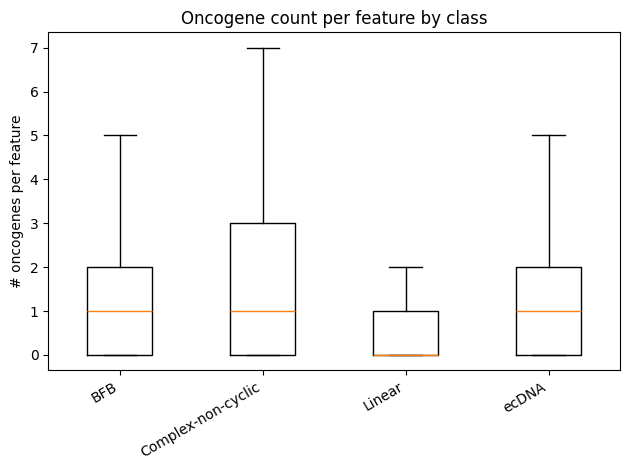

In [16]:
df_feat["oncogene_count"] = df_feat["oncogenes_list"].apply(lambda xs: len(set(xs)))

stats = (
    df_feat.groupby("Classification")["oncogene_count"]
    .describe(percentiles=[0.25,0.5,0.75,0.9])
)
print(stats)

# optional plot
classes = sorted(df_feat["Classification"].dropna().unique())
data = [df_feat.loc[df_feat["Classification"].eq(c), "oncogene_count"].values for c in classes]

plt.figure()
plt.boxplot(data, tick_labels=classes, showfliers=False)
plt.ylabel("# oncogenes per feature")
plt.title("Oncogene count per feature by class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
